**Βήμα 1ο**: Ανάγνωση δεδομένων

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes

# Εδώ θα φορτώσουμε τα δεδομένα, με την εντολή που αναφέρει η εκφώνηση
diabetes_data = load_diabetes(as_frame=True, scaled=False)
# Επεξήγηση παραμέτρων
# as_frame=True: Επιστρέφει τα δεδομένα σε δομή που περιέχει Pandas DataFrame.
# scaled=False: Φορτώνει τα πρωτογενή δεδομένα (όχι κανονικοποιημένα).

# Μετατροπή σε DataFrame
df = diabetes_data.frame

# Εκτύπωση επιτυχούς ανάγνωσης
print("Data loaded successfully!\n")

# Ενδεικτική εκτύπωση των 5 πρώτων γραμμών των δεδομένων
print(df.head())

# Σύντομη περιγραφή των δεδομένων με στατιστικά που είναι χρήσιμα για την περιγραφή του DataSet
df.describe()

Data loaded successfully!

    age  sex   bmi     bp     s1     s2    s3   s4      s5    s6  target
0  59.0  2.0  32.1  101.0  157.0   93.2  38.0  4.0  4.8598  87.0   151.0
1  48.0  1.0  21.6   87.0  183.0  103.2  70.0  3.0  3.8918  69.0    75.0
2  72.0  2.0  30.5   93.0  156.0   93.6  41.0  4.0  4.6728  85.0   141.0
3  24.0  1.0  25.3   84.0  198.0  131.4  40.0  5.0  4.8903  89.0   206.0
4  50.0  1.0  23.0  101.0  192.0  125.4  52.0  4.0  4.2905  80.0   135.0


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,48.518100,1.468326,26.375792,94.647014,189.140271,115.439140,49.788462,4.070249,4.641411,91.260181,152.133484
std,13.109028,0.499561,4.418122,13.831283,34.608052,30.413081,12.934202,1.290450,0.522391,11.496335,77.093005
min,19.000000,1.000000,18.000000,62.000000,97.000000,41.600000,22.000000,2.000000,3.258100,58.000000,25.000000
25%,38.250000,1.000000,23.200000,84.000000,164.250000,96.050000,40.250000,3.000000,4.276700,83.250000,87.000000
50%,50.000000,1.000000,25.700000,93.000000,186.000000,113.000000,48.000000,4.000000,4.620050,91.000000,140.500000
75%,59.000000,2.000000,29.275000,105.000000,209.750000,134.500000,57.750000,5.000000,4.997200,98.000000,211.500000
max,79.000000,2.000000,42.200000,133.000000,301.000000,242.400000,99.000000,9.090000,6.107000,124.000000,346.000000


**Βήμα 2ο**: Εκτύπωση εύρους τιμών για μία στήλη του DataFrame

In [2]:
# Διαλέγουμε την στήλη
column_name = 'target'
data_range = df[column_name].max() - df[column_name].min()

print(f"--- Range Analysis for column: {column_name} ---")
print(f"Max Value: {df[column_name].max()}")
print(f"Min Value: {df[column_name].min()}")
print(f"Range (Max - Min): {data_range}")


--- Range Analysis for column: target ---
Max Value: 346.0
Min Value: 25.0
Range (Max - Min): 321.0


**Βήμα 3ο**: Έλεγχος NaN τιμών και απομάκρυνση (εάν βρεθούν)

In [3]:
print("--- NaN Check ---")
if df.isnull().values.any():
    print("NaN values found. Removing corresponding rows...")
    initial_shape = df.shape

    # Απομάκρυνση των γραμμών με NaN
    df = df.dropna()

    print(f"Original shape: {initial_shape}")
    print(f"Shape after dropping NaNs: {df.shape}")
else:
    print("No NaN values found in the dataset.")

--- NaN Check ---
No NaN values found in the dataset.


**Βήμα 4ο**: Εκτύπωση γραφήματος συχνοτήτων για την στήλη "target"

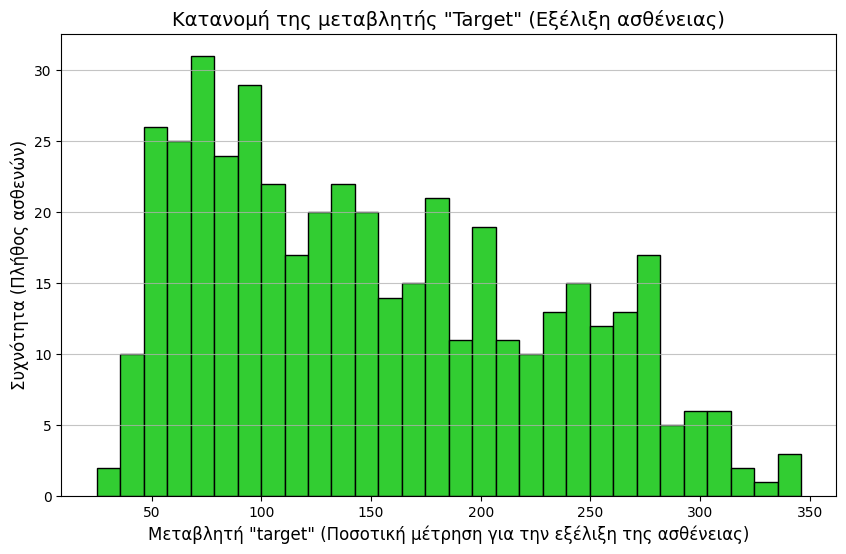

In [4]:
import matplotlib.pyplot as plt

# Δημιουργία του figure και του άξονα
plt.figure(figsize=(10, 6))

# Δημιουργία ιστογράμματος
# bins=30: Χωρίζουμε το εύρος τιμών σε 30 ίσα διαστήματα για καλή ανάλυση
# edgecolor='black': Προσθέτουμε περίγραμμα για να ξεχωρίζουν οι μπάρες
plt.hist(df['target'], bins=30, color='limegreen', edgecolor='black')

# Προσθήκη ετικετών και τίτλου
plt.title('Κατανομή της μεταβλητής "Target" (Εξέλιξη ασθένειας)', fontsize=14)
plt.xlabel('Μεταβλητή "target" (Ποσοτική μέτρηση για την εξέλιξη της ασθένειας)', fontsize=12)
plt.ylabel('Συχνότητα (Πλήθος ασθενών)', fontsize=12)

# Εμφάνιση πλέγματος για ευκολότερη ανάγνωση
plt.grid(axis='y', alpha=0.75)

# Εμφάνιση του γραφήματος
plt.show()

**Βήμα 5ο**: Κανονικοποίηση δεδομένων με την χρήση του Min-Max scaling

In [5]:
from sklearn.preprocessing import MinMaxScaler

# X: Δεδομένα Εισόδου. Όλες οι στήλες εκτός από την 'target'
# y: Δεδομένα Εξόδου. Μόνο η στήλη 'target'
X = df.drop(columns=['target'])
y = df['target']

# Δημιουργία ξεχωριστών Scalers
# scaler_X: Για τα 10 χαρακτηριστικά (input)
# scaler_y: Για τη μεταβλητή στόχο (output)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Εφαρμογή του Scaling (Fit & Transform)
# Το fit υπολογίζει τα Min/Max, το transform κάνει την πράξη
X_scaled = scaler_X.fit_transform(X)

# Η y είναι Series (1D), αλλά ο scaler θέλει 2D array.
# Χρησιμοποιούμε το .values.reshape(-1, 1) για να την κάνουμε στήλη.
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

# Μετατρέπουμε το y_scaled ξανά σε 1D array για να βολεύει στα μοντέλα (flatten)
y_scaled = y_scaled.flatten()

# Εκτύπωση για επιβεβαίωση
print("--- Normalization Complete ---")
print(f"X_scaled range: [{X_scaled.min():.2f}, {X_scaled.max():.2f}]")
print(f"y_scaled range: [{y_scaled.min():.2f}, {y_scaled.max():.2f}]")
print(f"Original y example: {y.iloc[0]}")
print(f"Scaled y example: {y_scaled[0]:.4f}")

--- Normalization Complete ---
X_scaled range: [0.00, 1.00]
y_scaled range: [0.00, 1.00]
Original y example: 151.0
Scaled y example: 0.3925


**Βήμα 6ο**: Ορισμός σταθερού seed

In [6]:
SEED = 42
print(f"Seed set to: {SEED}")

# Το Seed

Seed set to: 42


**Βήμα 7ο**: Χωρισμός δεδομένων σε 6 Folds, με χρήση του KFold

In [7]:
from sklearn.model_selection import KFold

# n_splits=6: Χωρίζουμε τα δεδομένα σε 6 μέρη (folds), όπως ζητάει η εκφώνηση.
# shuffle=True: Ανακατεύουμε τα δεδομένα πριν τα χωρίσουμε.
# random_state=SEED: Χρησιμοποιούμε το seed που ορίσαμε στο βήμα 6.
kf = KFold(n_splits=6, shuffle=True, random_state=SEED)

# Δημιουργούμε μια λίστα που περιέχει τα indices (δείκτες) για κάθε fold.
# Χρησιμοποιούμε το X_scaled (ή το X, το ίδιο είναι για το πλήθος) για να βρει το KFold πόσες γραμμές έχουμε.
# Η εντολή list(kf.split(...)) εκτελεί το μοίρασμα εδώ και αποθηκεύει τους δείκτες.
fold_indices = list(kf.split(X_scaled))

print(f"K-Fold Indices Generated.")
print(f"Total splits created: {len(fold_indices)}")

print(f"--- K-Fold Cross Validation Setup (6 Folds) ---")

# Τυπώνουμε πληροφορίες για ΚΑΘΕ fold
for i, (train_idx, test_idx) in enumerate(fold_indices):
    print(f"\nFold {i}:")
    print(f"  - Train samples: {len(train_idx)} indices")
    print(f"  - Test samples:  {len(test_idx)} indices")
    # Τυπώνουμε τα πρώτα 5 indices για να βλέπουμε ότι είναι τυχαία και διαφορετικά
    print(f"  - First 5 Train Indices: {train_idx[:5]}")
    print(f"  - First 5 Test Indices:  {test_idx[:5]}")

# Επιβεβαίωση ότι ΔΕΝ υπάρχουν επικαλύψεις στο Test set (κάθε δείκτης πρέπει να εμφανίζεται 1 φορά ως Test)
all_test_indices = []
for _, test_idx in fold_indices:
    all_test_indices.extend(test_idx)

print(f"\nTotal unique test indices: {len(set(all_test_indices))} (Should be 442)")

# Η λίστα 'fold_indices' περιέχει μόνο ακέραιους αριθμούς (διευθύνσεις γραμμών).
# Δεν έχει γίνει replicate των δεδομένων

K-Fold Indices Generated.
Total splits created: 6
--- K-Fold Cross Validation Setup (6 Folds) ---

Fold 0:
  - Train samples: 368 indices
  - Test samples:  74 indices
  - First 5 Train Indices: [1 2 3 4 5]
  - First 5 Test Indices:  [ 0  9 11 15 19]

Fold 1:
  - Train samples: 368 indices
  - Test samples:  74 indices
  - First 5 Train Indices: [0 1 2 4 6]
  - First 5 Test Indices:  [ 3  5  7 16 17]

Fold 2:
  - Train samples: 368 indices
  - Test samples:  74 indices
  - First 5 Train Indices: [0 1 3 4 5]
  - First 5 Test Indices:  [ 2  6 10 36 38]

Fold 3:
  - Train samples: 368 indices
  - Test samples:  74 indices
  - First 5 Train Indices: [0 1 2 3 4]
  - First 5 Test Indices:  [12 23 28 35 37]

Fold 4:
  - Train samples: 369 indices
  - Test samples:  73 indices
  - First 5 Train Indices: [0 1 2 3 5]
  - First 5 Test Indices:  [ 4  8 14 27 32]

Fold 5:
  - Train samples: 369 indices
  - Test samples:  73 indices
  - First 5 Train Indices: [0 2 3 4 5]
  - First 5 Test Indices:  [

**Βήμα 8ο**: Δημιουργία λίστας csv_data, για καταχώρηση αποτελεσμάτων αργότερα.

In [8]:
csv_data = []

# Προσθήκη της κεφαλίδας (Header row)
# Περιλαμβάνει τα metrics τόσο για τα κανονικοποιημένα (_n) όσο και για τα πραγματικά δεδομένα.
header = [
    "Model", "Set", "Fold",
    "Max_n", "RMSE_n", "MAE_n", "MAPE_n",
    "Max", "RMSE", "MAE", "MAPE"
]
csv_data.append(header)

print("--- CSV Data List Initialized ---")
print(f"Header created: {csv_data[0]}")

--- CSV Data List Initialized ---
Header created: ['Model', 'Set', 'Fold', 'Max_n', 'RMSE_n', 'MAE_n', 'MAPE_n', 'Max', 'RMSE', 'MAE', 'MAPE']


**Βήμα 9ο**: Εκπαίδευση μοντέλων

* Προετοιμασία και ορισμός μοντέλων

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Ορίζουμε ένα λεξικό (dictionary) που θα περιέχει:
# 1. Το όνομα του μοντέλου.
# 2. Το αντικείμενο του μοντέλου.
# 3. Το πλέγμα παραμέτρων (param_grid) για το RandomizedSearchCV.

model_setup = [
    {
        "name": "Random Forest",
        "model": RandomForestRegressor(random_state=SEED), # Βάζουμε SEED και εδώ
        "params": {
            # Πόσα δέντρα θα έχει το δάσος (π.χ. 50, 100 ή 200)
            "n_estimators": [50, 100, 200],
            # Το μέγιστο βάθος κάθε δέντρου (None σημαίνει απεριόριστο)
            "max_depth": [None, 10, 20, 30],
            # Ελάχιστα δείγματα για να χωριστεί ένας κόμβος
            "min_samples_split": [2, 5, 10]
        }
    },
    {
        "name": "Gaussian Process",
        # Το GPR θέλει έναν Kernel. Βάζουμε RBF (για την καμπύλη) + WhiteKernel (για τον θόρυβο).
        # Ο θόρυβος είναι απαραίτητος σε ιατρικά δεδομένα.
        "model": GaussianProcessRegressor(kernel=RBF() + WhiteKernel(), random_state=SEED),
        "params": {
            # Εδώ θα ψάξουμε την τιμή 'alpha' που διαχειρίζεται τον θόρυβο στις μετρήσεις
            "alpha": [1e-10, 1e-5, 1e-2, 0.1, 1.0],
            # Πόσες φορές θα επανεκκινήσει ο optimizer για να αποφύγει τοπικά ελάχιστα
            "n_restarts_optimizer": [0, 1, 2]
        }
    },
    {
        "name": "SVR", # Support Vector Regression (1η Επιλογή μας)
        "model": SVR(),
        "params": {
            # C: Πόσο αυστηρά τιμωρούμε τα λάθη (Regularization)
            "C": [0.1, 1, 10, 100],
            # kernel: Η μαθηματική συνάρτηση μετασχηματισμού
            "kernel": ["linear", "rbf", "poly"],
            # gamma: Πόσο επηρεάζει κάθε δείγμα (μόνο για rbf/poly)
            "gamma": ["scale", "auto"]
        }
    },
    {
        "name": "kNN", # k-Nearest Neighbors (2η Επιλογή μας)
        "model": KNeighborsRegressor(),
        "params": {
            # Πόσους γείτονες θα ρωτάμε (3, 5, 7, 9...)
            "n_neighbors": [3, 5, 7, 9, 11, 15],
            # Πώς θα ζυγίζουμε τη γνώμη τους (uniform=ίσα, distance=οι κοντινοί μετράνε πιο πολύ)
            "weights": ["uniform", "distance"]
        }
    }
]

print("Model configurations and hyperparameter grids are ready.")

Model configurations and hyperparameter grids are ready.


**Βήματα**: 9a, 9b, 9c, 9d, 9e

Κατασκευή συνάρτησης για τον υπολογισμό μετρικών

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, max_error, mean_absolute_percentage_error

def calculate_metrics(y_true, y_pred):
    # Υπολογισμός
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    max_err = max_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)

    return [max_err, rmse, mae, mape]

Δημιουργία φακέλου για εικόνες

In [11]:
import os
# Δημιουργία φακέλου για να αποθηκευτούν οι εικόνες
os.makedirs('plots', exist_ok=True)
print("Folder 'plots' created.")

Folder 'plots' created.


Εκπαίδευση των μοντέλων και υπολογισμός καλύτερων υπερπαραμέτρων με την
RandomizedSearchCV

Starting Training Process

=== Processing Fold 0 ===
  > Tuning & Training Random Forest...
    - Best Params found: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 30}
    > [Fold 0 - Random Forest] Test Real: RMSE=56.15, MAE=45.51, MAPE=40.57%


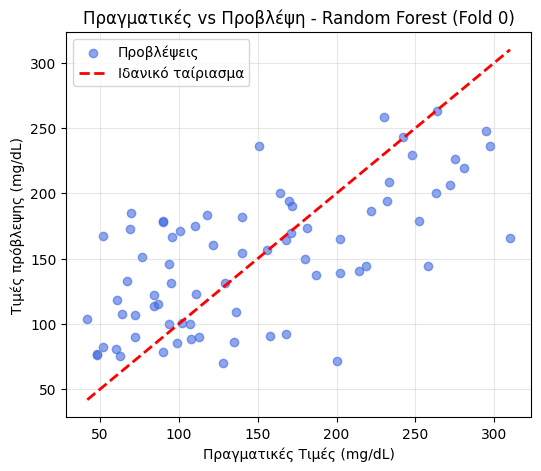

    > Generating SHAP plots for Random Forest (Fold 0)...


  0%|          | 0/10 [00:00<?, ?it/s]

      [Plot] SHAP Summary Plot for Random Forest


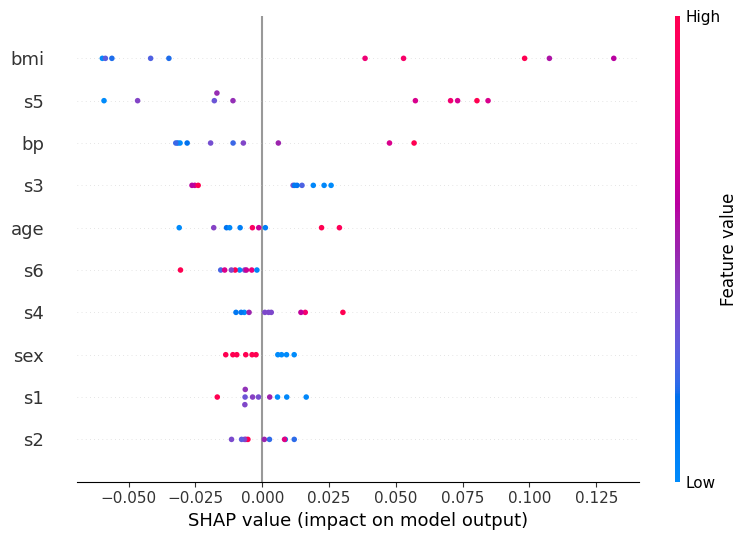

      [Plot] SHAP Waterfall Plot for Patient 0 (Random Forest)


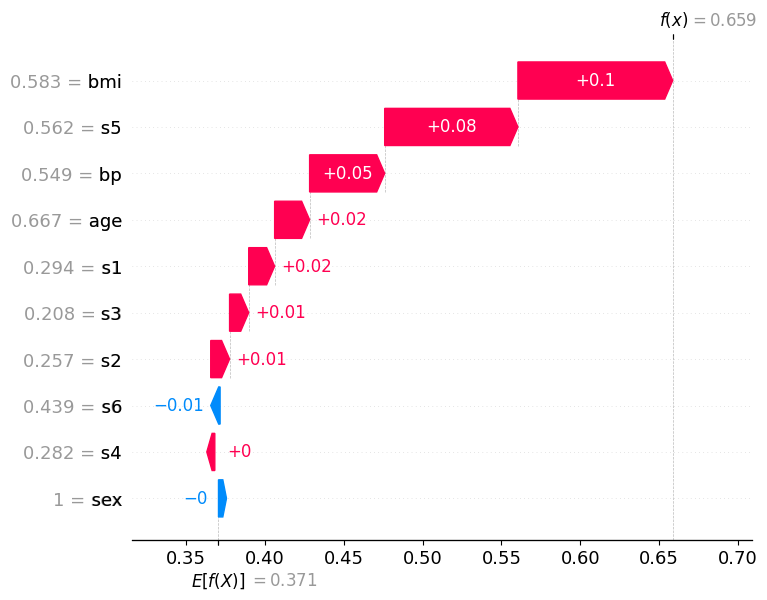

      [Plot] SHAP Waterfall Plot for Patient 1 (Random Forest)


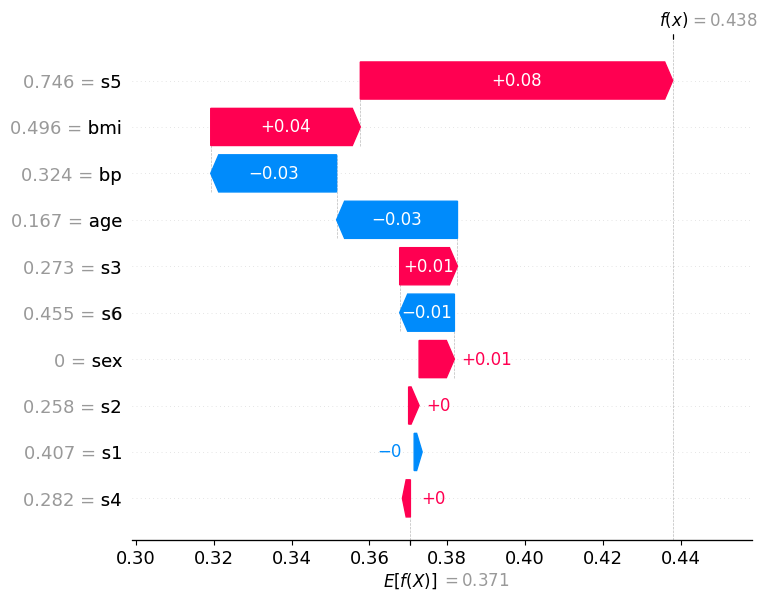

  > Tuning & Training Gaussian Process...
    - Best Params found: {'n_restarts_optimizer': 0, 'alpha': 1e-10}
    > [Fold 0 - Gaussian Process] Test Real: RMSE=54.54, MAE=44.12, MAPE=38.15%


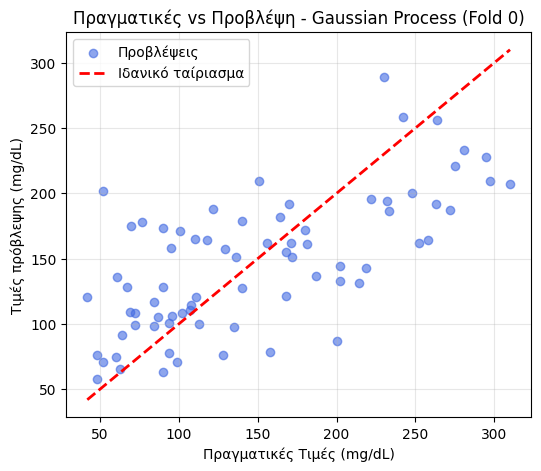

    > Generating SHAP plots for Gaussian Process (Fold 0)...


  0%|          | 0/10 [00:00<?, ?it/s]

      [Plot] SHAP Summary Plot for Gaussian Process


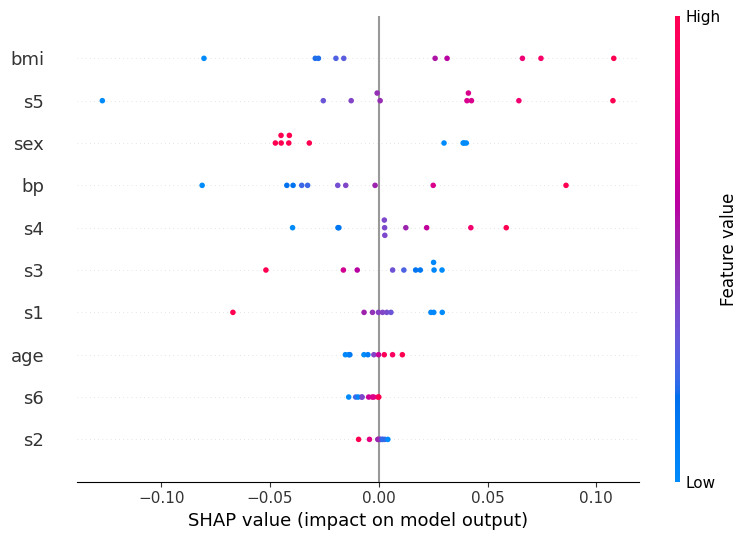

      [Plot] SHAP Waterfall Plot for Patient 0 (Gaussian Process)


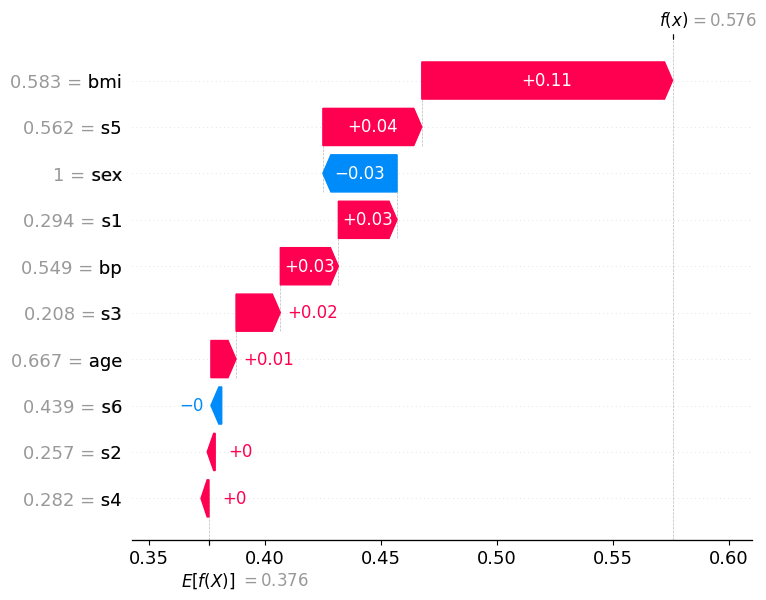

      [Plot] SHAP Waterfall Plot for Patient 1 (Gaussian Process)


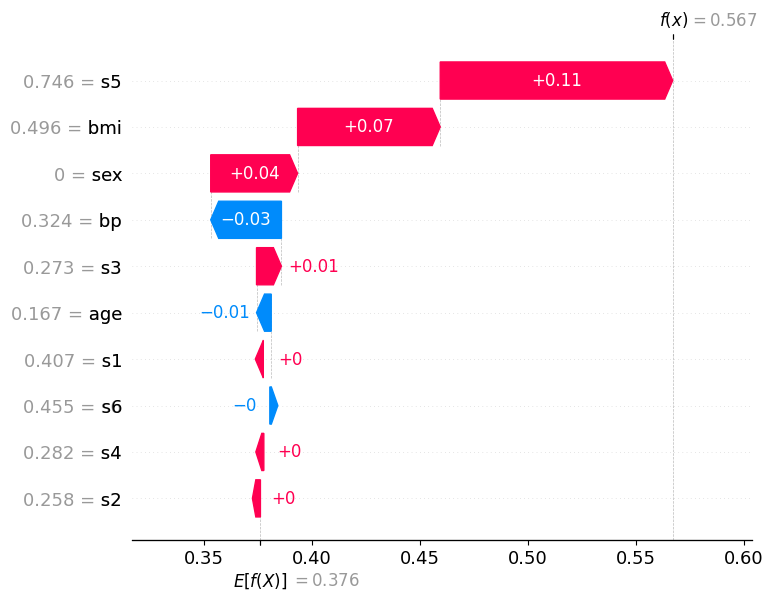

  > Tuning & Training SVR...
    - Best Params found: {'kernel': 'linear', 'gamma': 'scale', 'C': 0.1}
    > [Fold 0 - SVR] Test Real: RMSE=56.05, MAE=45.28, MAPE=39.06%


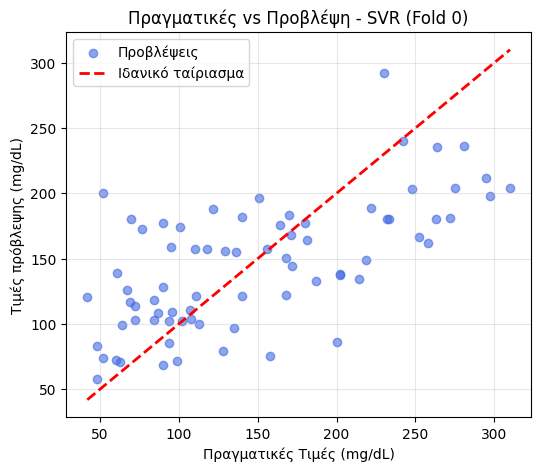

    > Generating SHAP plots for SVR (Fold 0)...


  0%|          | 0/10 [00:00<?, ?it/s]

      [Plot] SHAP Summary Plot for SVR


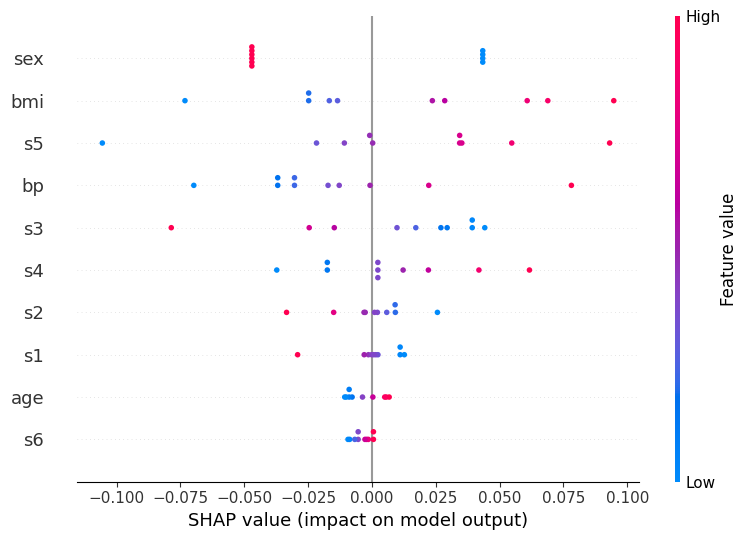

      [Plot] SHAP Waterfall Plot for Patient 0 (SVR)


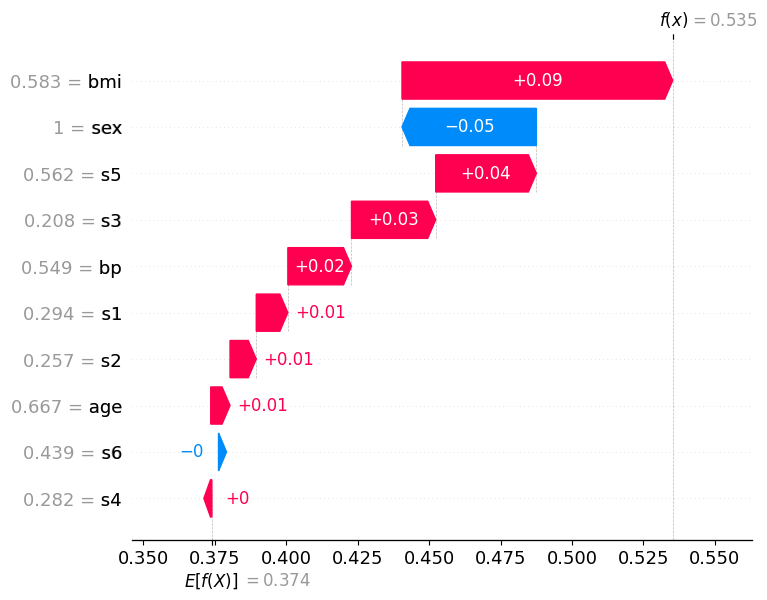

      [Plot] SHAP Waterfall Plot for Patient 1 (SVR)


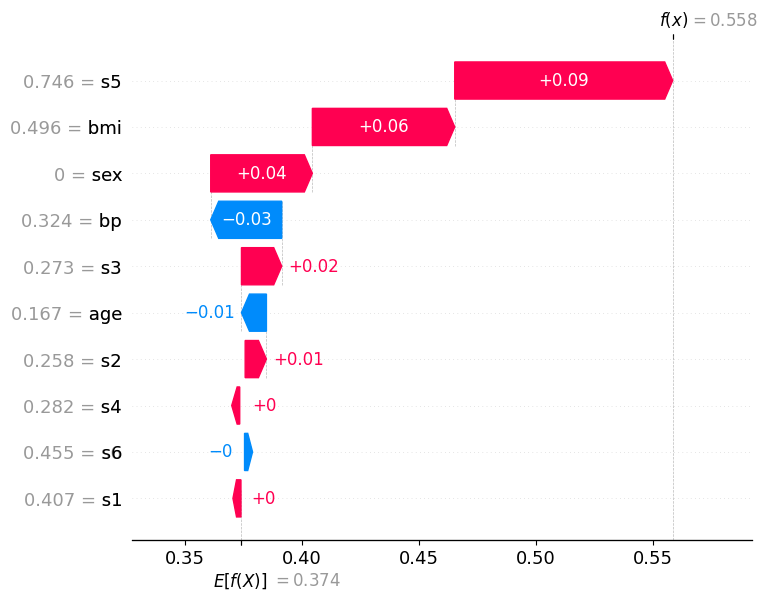

  > Tuning & Training kNN...
    - Best Params found: {'weights': 'distance', 'n_neighbors': 11}
    > [Fold 0 - kNN] Test Real: RMSE=55.76, MAE=44.47, MAPE=38.02%


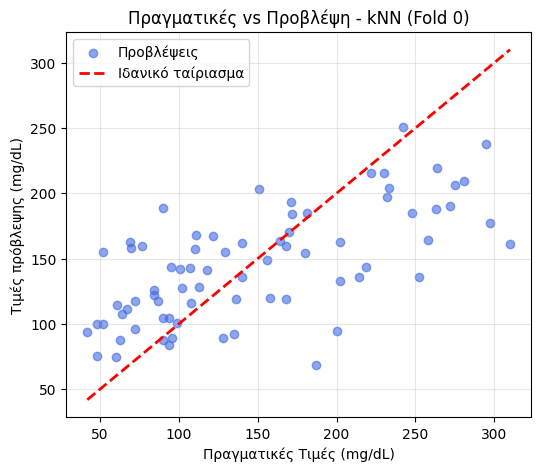

    > Generating SHAP plots for kNN (Fold 0)...


  0%|          | 0/10 [00:00<?, ?it/s]

      [Plot] SHAP Summary Plot for kNN


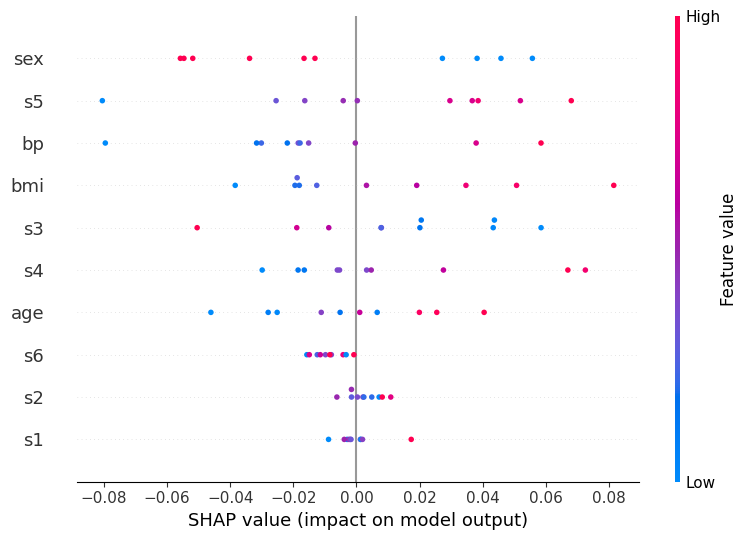

      [Plot] SHAP Waterfall Plot for Patient 0 (kNN)


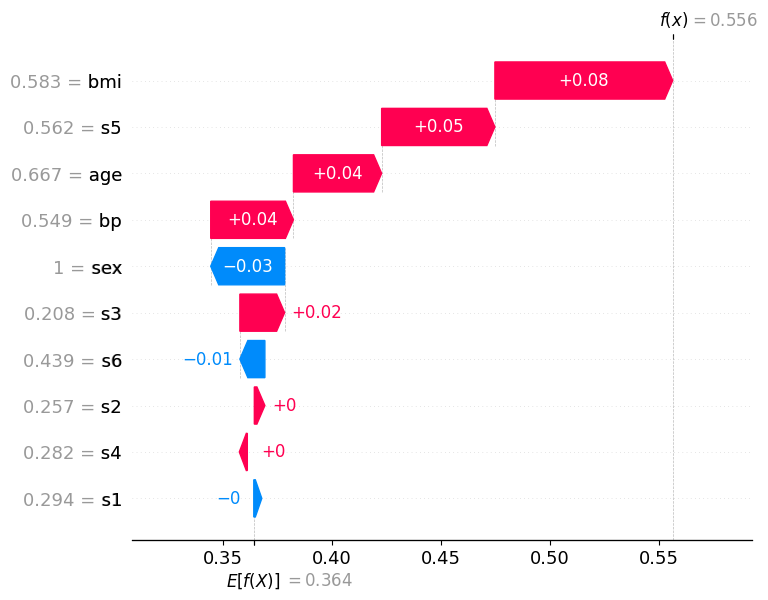

      [Plot] SHAP Waterfall Plot for Patient 1 (kNN)


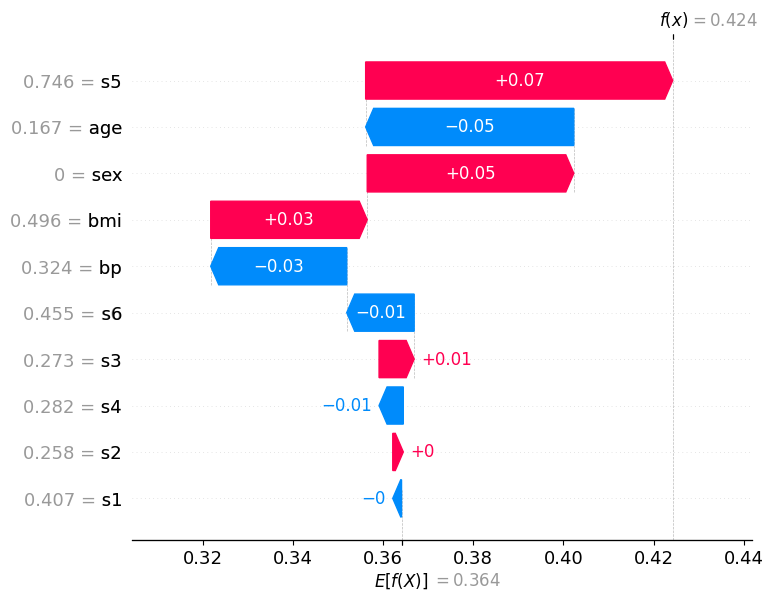


=== Processing Fold 1 ===
  > Tuning & Training Random Forest...
    - Best Params found: {'n_estimators': 200, 'min_samples_split': 10, 'max_depth': 30}
    > [Fold 1 - Random Forest] Test Real: RMSE=50.81, MAE=41.33, MAPE=34.15%
  > Tuning & Training Gaussian Process...
    - Best Params found: {'n_restarts_optimizer': 1, 'alpha': 1e-05}
    > [Fold 1 - Gaussian Process] Test Real: RMSE=48.04, MAE=37.95, MAPE=32.06%
  > Tuning & Training SVR...
    - Best Params found: {'kernel': 'rbf', 'gamma': 'scale', 'C': 0.1}
    > [Fold 1 - SVR] Test Real: RMSE=49.42, MAE=38.75, MAPE=33.09%
  > Tuning & Training kNN...
    - Best Params found: {'weights': 'distance', 'n_neighbors': 11}
    > [Fold 1 - kNN] Test Real: RMSE=55.20, MAE=42.41, MAPE=34.14%

=== Processing Fold 2 ===
  > Tuning & Training Random Forest...
    - Best Params found: {'n_estimators': 100, 'min_samples_split': 10, 'max_depth': 10}
    > [Fold 2 - Random Forest] Test Real: RMSE=65.46, MAE=55.67, MAPE=47.81%
  > Tuning & T

In [12]:
from sklearn.model_selection import RandomizedSearchCV
import warnings

# Απενεργοποίηση προειδοποιήσεων (warnings) για καθαρή έξοδο
warnings.filterwarnings('ignore')

print("Starting Training Process")

# --- Outer Loop: Επανάληψη για κάθε Fold (0 έως 5) ---
for fold_id, (train_idx, test_idx) in enumerate(fold_indices):

    print(f"\n=== Processing Fold {fold_id} ===")

    # --- Βήμα 9a: Προετοιμασία Train/Test Data ---
    # Χρησιμοποιούμε τους δείκτες (indices) για να "κόψουμε" τα numpy arrays.
    # X_train_fold, y_train_fold: Τα δεδομένα που θα δει το μοντέλο για να μάθει.
    # X_test_fold, y_test_fold: Τα δεδομένα που θα κρατήσουμε κρυφά για το prediction.
    X_train_fold = X_scaled[train_idx]
    y_train_fold = y_scaled[train_idx]

    X_test_fold = X_scaled[test_idx]
    y_test_fold = y_scaled[test_idx]

    # --- Inner Loop: Επανάληψη για κάθε Μοντέλο ---
    for model_info in model_setup:
        model_name = model_info['name']
        base_model = model_info['model']
        param_grid = model_info['params']

        print(f"  > Tuning & Training {model_name}...")

        # --- Βήμα 9b: RandomizedSearchCV ---
        # Εδώ γίνεται η αναζήτηση των καλύτερων υπερπαραμέτρων.
        # n_iter=10: Θα δοκιμάσει 10 τυχαίους συνδυασμούς ρυθμίσεων.
        # cv=3: Εσωτερικό Cross-Validation (Nested CV). Το Train set χωρίζεται ξανά σε 3 μέρη
        #       για να βρεθεί η καλύτερη ρύθμιση, πριν εκπαιδευτεί στο σύνολο.
        # scoring: Προσπαθούμε να ελαχιστοποιήσουμε το λάθος (neg_mean_squared_error).
        random_search = RandomizedSearchCV(
            estimator=base_model,
            param_distributions=param_grid,
            n_iter=10,             # Αριθμός τυχαίων δοκιμών
            scoring='neg_mean_squared_error',
            cv=3,                  # 3-fold CV μέσα στο train set
            random_state=SEED,     # Για επαναληψιμότητα
            n_jobs=-1              # Χρήση όλων των πυρήνων του CPU για ταχύτητα
        )

        # Εκπαίδευση (Fit) πάνω στα TRAIN data του συγκεκριμένου fold
        random_search.fit(X_train_fold, y_train_fold)

        # Αποθήκευση του "νικητή" μοντέλου (best_estimator_)
        # Αυτό είναι το μοντέλο που θα χρησιμοποιήσουμε για προβλέψεις στο επόμενο βήμα.
        best_model = random_search.best_estimator_
        best_params = random_search.best_params_

        print(f"    - Best Params found: {best_params}")

        # --- Βήμα 9c: Prediction ---
        # Πρόβλεψη σε Train και Test (τιμές 0-1 ακόμα)
        y_pred_train_scaled = best_model.predict(X_train_fold)
        y_pred_test_scaled = best_model.predict(X_test_fold)

        # --- Βήμα 9d: Denormalize (Επαναφορά στο πραγματικό εύρος) ---

        # Η συνάρτηση inverse_transform του scaler θέλει δισδιάστατο πίνακα (2D array).
        # Γι' αυτό χρησιμοποιούμε το .reshape(-1, 1).
        # Μετά χρησιμοποιούμε το .flatten() για να το ξανακάνουμε απλή λίστα (1D).

        # 1. Για το Train Set (Πραγματικά και Προβλέψεις)
        y_train_real = scaler_y.inverse_transform(y_train_fold.reshape(-1, 1)).flatten()
        y_pred_train_real = scaler_y.inverse_transform(y_pred_train_scaled.reshape(-1, 1)).flatten()

        # 2. Για το Test Set (Πραγματικά και Προβλέψεις)
        # Αυτά θα χρησιμοποιήσουμε για την τελική αξιολόγηση
        y_test_real = scaler_y.inverse_transform(y_test_fold.reshape(-1, 1)).flatten()
        y_pred_test_real = scaler_y.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).flatten()

        # --- Βήμα 9e: Υπολογισμός error metrics ---

        # 1. Υπολογισμός για Train Set (Normalized & Real)
        # Η συνάρτηση επιστρέφει λίστα [Max, RMSE, MAE, MAPE]
        train_metrics_n = calculate_metrics(y_train_fold, y_pred_train_scaled)
        train_metrics_r = calculate_metrics(y_train_real, y_pred_train_real)

        # 2. Υπολογισμός για Test Set (Normalized & Real)
        test_metrics_n = calculate_metrics(y_test_fold, y_pred_test_scaled)
        test_metrics_r = calculate_metrics(y_test_real, y_pred_test_real)

        # Εκτύπωση για έλεγχο (μόνο για το ένα μοντέλο σε κάθε fold για να μην γεμίσει η οθόνη)
        print(f"    > [Fold {fold_id} - {model_name}] Test Real: "
              f"RMSE={test_metrics_r[1]:.2f}, "   # Index 1
              f"MAE={test_metrics_r[2]:.2f}, "    # Index 2
              f"MAPE={test_metrics_r[3]:.2%}")    # Index 3 (μορφοποίηση ως ποσοστό %)

        # --- Βήμα 9f: Γράφημα Actual vs Predicted ---

        # Περιορίζουμε την εκτύπωση μόνο στο Fold 0
        # (Θα παραχθούν 4 γραφήματα, ένα για κάθε μοντέλο του Fold 0)
        if fold_id == 0:
            plt.figure(figsize=(6, 5))

            # 1. Τα σημεία (Scatter Plot)
            # Άξονας Χ: Πραγματικές Τιμές
            # Άξονας Υ: Προβλέψεις
            plt.scatter(y_test_real, y_pred_test_real, color='royalblue', alpha=0.6, label='Προβλέψεις')

            # 2. Η Ιδανική Γραμμή (Identity Line y=x)
            # Αν ένα σημείο πέσει πάνω στην κόκκινη γραμμή, σημαίνει Πρόβλεψη = Πραγματικότητα (Τέλειο)
            # Υπολογίζουμε τα όρια για να τραβήξουμε τη γραμμή από άκρη σε άκρη
            p_min = min(y_test_real.min(), y_pred_test_real.min())
            p_max = max(y_test_real.max(), y_pred_test_real.max())
            plt.plot([p_min, p_max], [p_min, p_max], 'r--', lw=2, label='Ιδανικό ταίριασμα')

            # Τίτλοι και Ετικέτες
            plt.title(f'Πραγματικές vs Προβλέψη - {model_name} (Fold {fold_id})')
            plt.xlabel('Πραγματικές Τιμές (mg/dL)')
            plt.ylabel('Τιμές πρόβλεψης (mg/dL)')
            plt.legend()
            plt.grid(True, alpha=0.3)

            # Αποθήκευση
            clean_name = model_name.replace(" ", "_")
            filename = f"plots/Fold{fold_id}_{clean_name}_ActualVsPred.png"
            plt.savefig(filename, bbox_inches='tight', dpi=300)

            # Εμφάνιση
            plt.show()


        # --- Βήμα 9g: Append στο csv data ---
        # Γραμμή Train: [Model, Set, Fold] + [Metrics_n] + [Metrics_r]
        # Το '+' ενώνει τις λίστες
        csv_data.append([model_name, "Train", fold_id] + train_metrics_n + train_metrics_r)

        # Γραμμή Test
        csv_data.append([model_name, "Test", fold_id] + test_metrics_n + test_metrics_r)

        # --- Βήμα 9h: SHAP Explainability ---

        if fold_id == 0:
            import shap

            shap.initjs()

            print(f"    > Generating SHAP plots for {model_name} (Fold 0)...")

            # 1. Δημιουργία του Explainer
            # Χρησιμοποιούμε ένα δείγμα (summary) του Train set για ταχύτητα,
            # αλλιώς το KernelExplainer θα είναι υπερβολικά αργό.
            # Το shap.sample παίρνει 50 τυχαία δείγματα από το train set ως "background".
            background_summary = shap.sample(X_train_fold, 50)

            # Δημιουργούμε τον explainer γενικής χρήσης.
            # Το best_model.predict είναι η συνάρτηση πρόβλεψης.
            explainer = shap.KernelExplainer(best_model.predict, background_summary)

            # 2. Υπολογισμός SHAP values για το TEST set
            # (Επιλέγουμε ένα μικρό κομμάτι του Test set για να μην αργήσει, π.χ. τα πρώτα 10 άτομα)
            X_test_sample = X_test_fold[:10]
            shap_values = explainer.shap_values(X_test_sample)

            # Καθαρό όνομα για το αρχείο
            clean_name = model_name.replace(" ", "_")

            # --- Plot 1: Summary Plot ---
            # Δείχνει ποια χαρακτηριστικά είναι τα πιο σημαντικά συνολικά.
            print(f"      [Plot] SHAP Summary Plot for {model_name}")
            plt.figure() # Νέο figure για να μην πέσει το ένα πάνω στο άλλο
            shap.summary_plot(shap_values, X_test_sample, feature_names=df.drop(columns=['target']).columns, show=False)

            filename_sum = f"plots/Fold{fold_id}_{clean_name}_SHAP_Summary.png"
            plt.savefig(filename_sum, bbox_inches='tight', dpi=300)
            plt.show()

            # --- Plot 2: Waterfall Plots (για 2 παραδείγματα) ---
            # Θα πάρουμε τον πρώτο (index 0) και τον δεύτερο (index 1) ασθενή από το test sample.

            # Το KernelExplainer επιστρέφει np.array, αλλά το waterfall θέλει αντικείμενο Explanation.
            # Φτιάχνουμε το αντικείμενο Explanation χειροκίνητα για συμβατότητα.
            explanation = shap.Explanation(
                values=shap_values,
                base_values=explainer.expected_value,
                data=X_test_sample,
                feature_names=df.drop(columns=['target']).columns
            )

            # Παράδειγμα 1 (Ασθενής 0)
            print(f"      [Plot] SHAP Waterfall Plot for Patient 0 ({model_name})")
            plt.figure()
            shap.plots.waterfall(explanation[0], show=False)

            filename_wf1 = f"plots/Fold{fold_id}_{clean_name}_SHAP_Waterfall_Pat0.png"
            plt.savefig(filename_wf1, bbox_inches='tight', dpi=300)

            plt.show()

            # Παράδειγμα 2 (Ασθενής 1)
            print(f"      [Plot] SHAP Waterfall Plot for Patient 1 ({model_name})")
            plt.figure()
            shap.plots.waterfall(explanation[1], show=False)

            filename_wf2 = f"plots/Fold{fold_id}_{clean_name}_SHAP_Waterfall_Pat1.png"
            plt.savefig(filename_wf2, bbox_inches='tight', dpi=300)

            plt.show()

Αποθήκευση αποτελεσμάτων στο csv

In [13]:
# --- Δημιουργία DataFrame και Εξαγωγή ---

# Μετατρέπουμε τη λίστα λιστών (csv_data) σε Pandas DataFrame
# Η πρώτη γραμμή της λίστας περιέχει τα ονόματα των στηλών (Headers)
results_df = pd.DataFrame(csv_data[1:], columns=csv_data[0])

# Αποθηκεύουμε σε αρχείο CSV
filename = "diabetes_model_results.csv"
results_df.to_csv(filename, index=False)
print(f"Results saved to file: {filename}")

# --- Εμφάνιση των αποτελεσμάτων ---
print("\n--- Detailed Results (First 10 rows) ---")
# Τυπώνουμε τις πρώτες γραμμές για να δούμε τη μορφή
print(results_df.head(10))


# Ο πίνακας έχει πολλές γραμμές (6 folds x 4 μοντέλα x 2 sets = 48 γραμμές).

# Φιλτράρουμε μόνο τις γραμμές του Test set
test_results = results_df[results_df["Set"] == "Test"]

# Μετατρέπουμε τις στήλες με νούμερα σε αριθμητική μορφή
cols_to_mean = ["RMSE", "MAE", "MAPE", "Max"]
for col in cols_to_mean:
    test_results[col] = pd.to_numeric(test_results[col])

# Ομαδοποίηση ανά Μοντέλο και υπολογισμός Μέσου Όρου
summary = test_results.groupby("Model")[cols_to_mean].mean()

print("\n--- Average Performance on Test Set (All 6 Folds) ---")
print(summary)

Results saved to file: diabetes_model_results.csv

--- Detailed Results (First 10 rows) ---
              Model    Set  Fold     Max_n    RMSE_n     MAE_n        MAPE_n  \
0     Random Forest  Train     0  0.224245  0.077637  0.062202  1.608681e+12   
1     Random Forest   Test     0  0.449854  0.174918  0.141782  6.057240e-01   
2  Gaussian Process  Train     0  0.488422  0.163566  0.132604  4.544248e+12   
3  Gaussian Process   Test     0  0.467875  0.169898  0.137437  5.740275e-01   
4               SVR  Train     0  0.500396  0.167015  0.135192  4.626186e+12   
5               SVR   Test     0  0.461748  0.174616  0.141051  5.890763e-01   
6               kNN  Train     0  0.000000  0.000000  0.000000  0.000000e+00   
7               kNN   Test     0  0.463620  0.173697  0.138522  5.701762e-01   
8     Random Forest  Train     1  0.294683  0.102440  0.082853  1.732304e+12   
9     Random Forest   Test     1  0.415422  0.158280  0.128748  5.237030e-01   

          Max       RMSE   